In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
from EMDPM.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os
import glob

# Find all grid search result files
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/2026_2_11_ppmi_subtyping_bic_v3/results"
pattern = os.path.join(result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")




Found 383 result files

Total loaded: 383 results


In [187]:
# Extract summary statistics for all models
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        # Extract final values
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan

        # Extract cluster parameters
        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]
            n_subtypes = cluster_f.shape[0]
            # Sparsity: count of f entries below 0.01 (across all clusters)
            f_sparsity = int(np.sum(cluster_f < 0.01))
        else:
            cluster_f = None
            n_subtypes = 0
            f_sparsity = np.nan

        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan

        # Extract candidate number
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])

        # Extract lambda parameters
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        lambda_f = data["lambda_f"] if "lambda_f" in data.files else np.nan
        lambda_scalar = data["lambda_scalar"] if "lambda_scalar" in data.files else np.nan

        # Extract assignment statistics
        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []

        bic = float(data["bic"]) if "bic" in data.files else np.nan
        cv_mean_lse = float(data["cv_mean_lse"]) if "cv_mean_lse" in data.files else np.nan

        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "cv_mean_lse": cv_mean_lse,
            "bic": bic,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "lambda_cog": lambda_cog,
            "lambda_jsd": lambda_jsd,
            "lambda_f": lambda_f,
            "lambda_scalar": lambda_scalar,
            "f_sparsity": f_sparsity,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("cv_mean_lse").reset_index(drop=True)
print("\nSummary Statistics (sorted by CV LSE)")
print(summary_df[["candidate", "final_lse", "cv_mean_lse", "bic", "n_subtypes", "scalar_K", "mean_s", "lambda_cog", "lambda_jsd", "lambda_f", "lambda_scalar", "f_sparsity"]].head(10))


Summary Statistics (sorted by CV LSE)
  candidate   final_lse  cv_mean_lse           bic  n_subtypes  \
0       101  451.578311   185.924541 -32259.741131           2   
1       271  431.390836   187.642203 -32036.084852           4   
2        11  482.720657   193.613833 -30441.256436           2   
3        56  452.778246   195.150860 -32187.380616           2   
4       236  536.715405   196.168295 -26814.664836           3   
5       181  435.560654   199.790233 -32509.148153           3   
6        29  562.891467   200.204506 -26251.563758           2   
7        50  499.652765   200.367361 -29501.185276           2   
8       276  436.819238   200.861918 -31695.099172           4   
9       186  565.135881   200.969014 -25407.684612           3   

                scalar_K    mean_s lambda_cog lambda_jsd lambda_f  \
0                    0.0  0.634123        0.0         10     0.75   
1                    0.0  0.590746        0.0         10     0.25   
2                    0.0  0

### MODEL SELECTION

In [188]:
#inspect_candidate = 236
inspect_candidate = None

if inspect_candidate is None:
    # 2-stage selection
    # Stage 1: For each K (n_subtypes), pick hyperparameters with lowest CV LSE
    # Stage 2: Among those best-per-K models, pick the one with best (lowest) BIC
    df_bic = summary_df[summary_df["bic"].notna()].copy()
    if len(df_bic) == 0:
        best_row = summary_df.sort_values("cv_mean_lse").iloc[0]
        best_key = best_row["key"]
        best_data = results[best_key]
        print("\nBEST MODEL (by CV LSE, no BIC in results)")
    else:
        best_per_K = df_bic.loc[df_bic.groupby("n_subtypes")["cv_mean_lse"].idxmin()]
        idx_best = best_per_K["bic"].idxmin()
        best_row = best_per_K.loc[idx_best]
        best_key = best_row["key"]
        best_data = results[best_key]
        print("\nBEST MODEL (2-stage: best CV LSE per K, then best BIC among those)")
        print("Stage 1 - Best per K (by CV LSE):")
        for _, r in best_per_K.sort_values("n_subtypes").iterrows():
            print(f"  K={int(r['n_subtypes'])}: candidate={r['candidate']}, cv_mean_lse={r['cv_mean_lse']:.6f}, bic={r['bic']:.4f}")
        print(f"\nStage 2 - Selected K={int(best_row['n_subtypes'])} (lowest BIC among above).")
else:
    # Inspect specific candidate
    match = summary_df[summary_df["candidate"] == inspect_candidate]
    if len(match) == 0:
        raise ValueError(f"No result found for candidate {inspect_candidate}")
    best_row = match.iloc[0]
    best_key = best_row["key"]
    best_data = results[best_key]
    print(f"\nINSPECTING CANDIDATE {inspect_candidate} (best_* set to this run)")

print(f"Key: {best_key}")
print(f"n_subtypes: {best_row['n_subtypes']}, Final LSE: {best_row['final_lse']:.6f}")
if "bic" in best_row and pd.notna(best_row["bic"]):
    print(f"BIC: {best_row['bic']:.4f}, CV mean LSE: {best_row['cv_mean_lse']:.6f}")
if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")


BEST MODEL (2-stage: best CV LSE per K, then best BIC among those)
Stage 1 - Best per K (by CV LSE):
  K=2: candidate=101, cv_mean_lse=185.924541, bic=-32259.7411
  K=3: candidate=236, cv_mean_lse=196.168295, bic=-26814.6648
  K=4: candidate=271, cv_mean_lse=187.642203, bic=-32036.0849

Stage 2 - Selected K=2 (lowest BIC among above).
Key: PPMI_subtyping_grid_betajsd_101_lambda_f0p750_lambda_cog0p000_lambda_scalar1p100_lambda_jsd10_lambda_beta0p000_n_subtypes2
n_subtypes: 2, Final LSE: 451.578311
BIC: -32259.7411, CV mean LSE: 185.924541

Parameters:
  lambda_f: 0.75
  lambda_cog: 0.0
  lambda_scalar: 1.1
  lambda_jsd: 10
  lambda_beta: 0.0


In [189]:
# Find best candidates for transform LSE (with and without cognitive priors)
transform_summary = []

for cand, data in results.items():
    try:
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract validation LSE values
        val_lse_with_cog = data["val_lse_with_cog"] if "val_lse_with_cog" in data.files else np.nan
        val_lse_no_cog = data["val_lse_no_cog"] if "val_lse_no_cog" in data.files else np.nan
        
        # Extract parameters
        lambda_f = data["lambda_f"] if "lambda_f" in data.files else np.nan
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_scalar = data["lambda_scalar"] if "lambda_scalar" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        lambda_beta = data["lambda_beta"] if "lambda_beta" in data.files else np.nan
        
        transform_summary.append({
            "candidate": candidate_num,
            "key": cand,
            "val_lse_with_cog": val_lse_with_cog,
            "val_lse_no_cog": val_lse_no_cog,
            "lambda_f": lambda_f,
            "lambda_cog": lambda_cog,
            "lambda_scalar": lambda_scalar,
            "lambda_jsd": lambda_jsd,
            "lambda_beta": lambda_beta,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

transform_df = pd.DataFrame(transform_summary)

print(transform_df.shape)


(383, 9)


In [190]:
# Use the best model (lowest training LSE) for both with and without cognitive priors
print(f"Key: {best_key}")
print(f"Training LSE: {best_row['final_lse']:.6f}")

# Get validation LSE values from best_data if available
val_lse_with_cog = best_data["val_lse_with_cog"] if "val_lse_with_cog" in best_data.files else np.nan
val_lse_no_cog = best_data["val_lse_no_cog"] if "val_lse_no_cog" in best_data.files else np.nan

print(f"Validation LSE (with cog): {val_lse_with_cog:.6f}")
print(f"Validation LSE (no cog): {val_lse_no_cog:.6f}")

if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")

# Get subtype assignments from best_data
train_assignments = best_data['train_assignments']
val_with = best_data['val_assignments_with_cog'] if 'val_assignments_with_cog' in best_data.files else []
val_no = best_data['val_assignments_no_cog'] if 'val_assignments_no_cog' in best_data.files else []
n_subtypes = len(np.unique(train_assignments))

print(f"\nTraining Set")
print(f"Subtype counts:")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(train_assignments == k)} patients")
print(f"  Total: {len(train_assignments)} patients")

print(f"\nValidation Set")
print(f"Subtype counts (with cog):")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_with == k)} patients")
print(f"  Total: {len(val_with)} patients")

print(f"\nSubtype counts (no cog):")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_no == k)} patients")
print(f"  Total: {len(val_no)} patients")

Key: PPMI_subtyping_grid_betajsd_101_lambda_f0p750_lambda_cog0p000_lambda_scalar1p100_lambda_jsd10_lambda_beta0p000_n_subtypes2
Training LSE: 451.578311
Validation LSE (with cog): 143.413684
Validation LSE (no cog): 143.413684

Parameters:
  lambda_f: 0.75
  lambda_cog: 0.0
  lambda_scalar: 1.1
  lambda_jsd: 10
  lambda_beta: 0.0

Training Set
Subtype counts:
  Subtype 0: 72 patients
  Subtype 1: 44 patients
  Total: 116 patients

Validation Set
Subtype counts (with cog):
  Subtype 0: 28 patients
  Subtype 1: 2 patients
  Total: 30 patients

Subtype counts (no cog):
  Subtype 0: 28 patients
  Subtype 1: 2 patients
  Total: 30 patients


### hist of transform LSE differences

/tmp/ipykernel_471/741470681.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


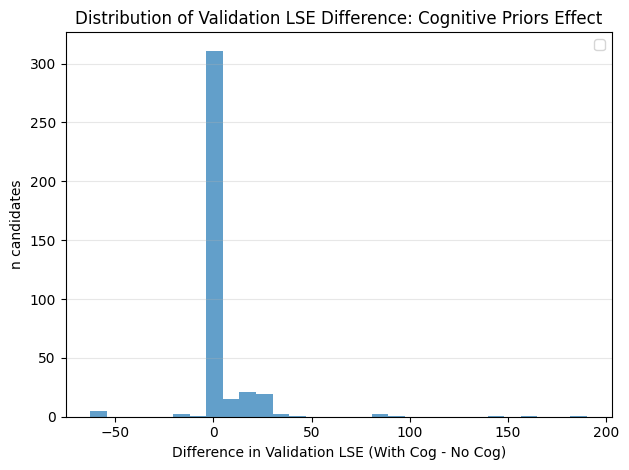

22 233


In [191]:
transform_df["lse_diff"] = transform_df["val_lse_with_cog"] - transform_df["val_lse_no_cog"]
valid_diff = transform_df.dropna(subset=["lse_diff"])

# Plot histogram
plt.hist(valid_diff['lse_diff'], bins=30, alpha=0.7)
plt.xlabel('Difference in Validation LSE (With Cog - No Cog)')
plt.ylabel('n candidates')
plt.title('Distribution of Validation LSE Difference: Cognitive Priors Effect')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

n_better_with_cog = (valid_diff['lse_diff'] < 0).sum()
n_worse_with_cog = (valid_diff['lse_diff'] > 0).sum()
print(n_better_with_cog, n_worse_with_cog)    

In [192]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")
## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [193]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

print(f"Training patients: {len(train_ids)}")
print(f"Validation patients: {len(val_ids)}")

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

# Count unique patients per subtype (not observations!)
unique_valid_pids = np.unique(ids_valid)
patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in unique_valid_pids])

n_subtypes = len(np.unique(patient_assignments[patient_assignments >= 0]))
print(f"Total subject: {len(unique_valid_pids)}\n")
for k in range(n_subtypes):
    print(f"Subtype {k}: {np.sum(patient_assignments == k)} patients")

# Breakdown by train vs validation
train_patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in train_ids])
val_patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in val_ids])

print(f"\nTraining set:")
print(f"  Total: {len(train_ids)} patients")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(train_patient_assignments == k)} patients")

print(f"\nValidation set:")
print(f"  Total: {len(val_ids)} patients")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_patient_assignments == k)} patients")

Training patients: 116
Validation patients: 30
Total subject: 146

Subtype 0: 100 patients
Subtype 1: 46 patients

Training set:
  Total: 116 patients
  Subtype 0: 72 patients
  Subtype 1: 44 patients

Validation set:
  Total: 30 patients
  Subtype 0: 28 patients
  Subtype 1: 2 patients



Subtype 0:
  Intercept (cog_b): 32.4203
  MCATOT coefficient: -0.5775
  TD_score coefficient: -0.0299
  PIGD_score coefficient: 1.0910
s_ij = 32.4203 +-0.5775 * MCATOT +-0.0299 * TD +1.0910 * PIGD

Subtype 1:
  Intercept (cog_b): 23.7799
  MCATOT coefficient: 0.0147
  TD_score coefficient: -0.0218
  PIGD_score coefficient: 0.5212
s_ij = 23.7799 +0.0147 * MCATOT +-0.0218 * TD +0.5212 * PIGD


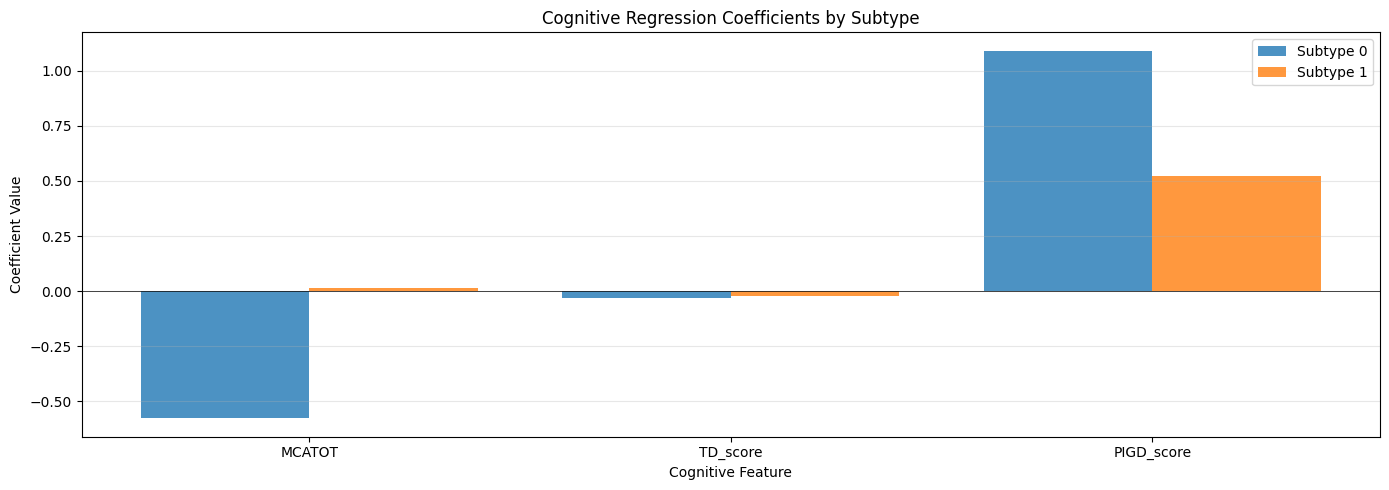

In [194]:
# Cognitive Parameter Comparison (general for any number of subtypes from best model)
cluster_cog_a = np.asarray(best_data["cluster_cog_a"])  # (n_subtypes, n_cog_features)
cluster_cog_b = np.atleast_1d(np.asarray(best_data["cluster_cog_b"]))  # (n_subtypes,)
n_subtypes = cluster_cog_b.shape[0]  # derive from data so it matches loaded arrays

cog_feature_names = ['MCATOT', 'TD_score', 'PIGD_score']

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

    print(f"s_ij = {cluster_cog_b[subtype]:.4f} +\
{cluster_cog_a[subtype, 0]:.4f} * MCATOT +\
{cluster_cog_a[subtype, 1]:.4f} * TD +\
{cluster_cog_a[subtype, 2]:.4f} * PIGD")


# Plot comparison (general for any n_subtypes)
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
x = np.arange(len(cog_feature_names))
width = 0.8 / n_subtypes
for subtype in range(n_subtypes):
    offset = (subtype - (n_subtypes - 1) / 2) * width
    ax.bar(x + offset, cluster_cog_a[subtype], width, label=f'Subtype {subtype}', alpha=0.8)
ax.set_xlabel('Cognitive Feature')
ax.set_ylabel('Coefficient Value')
ax.set_title('Cognitive Regression Coefficients by Subtype')
ax.set_xticks(x)
ax.set_xticklabels(cog_feature_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

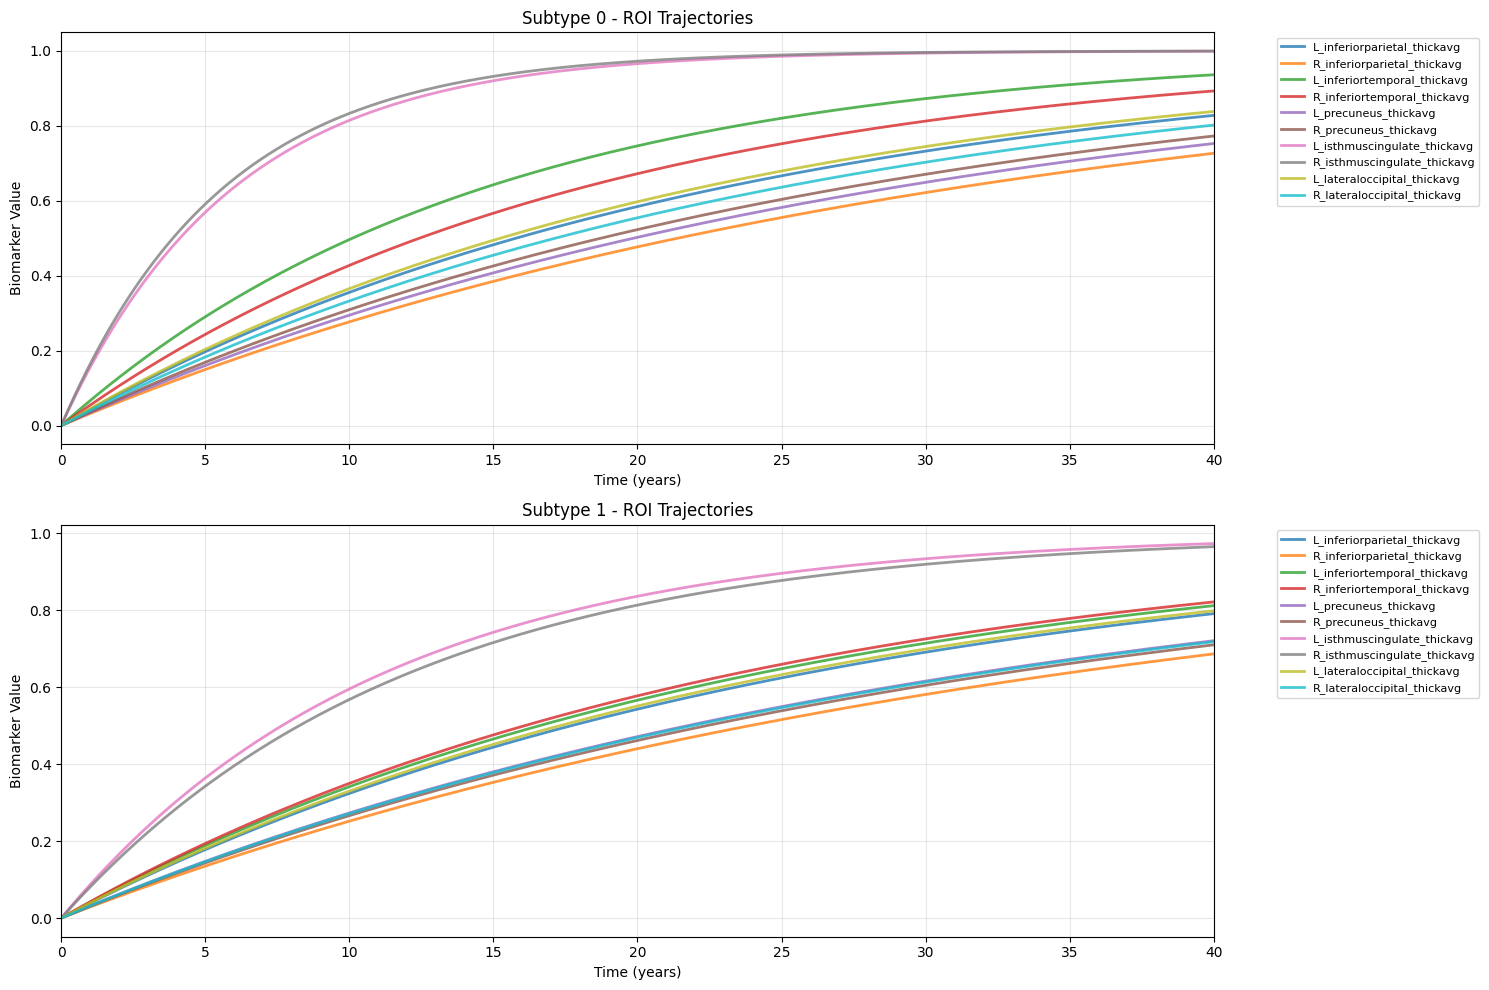

In [195]:
# ROI Subplots: 10 ROI trajectories for each subtype
cluster_f = best_data["cluster_f"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)

    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

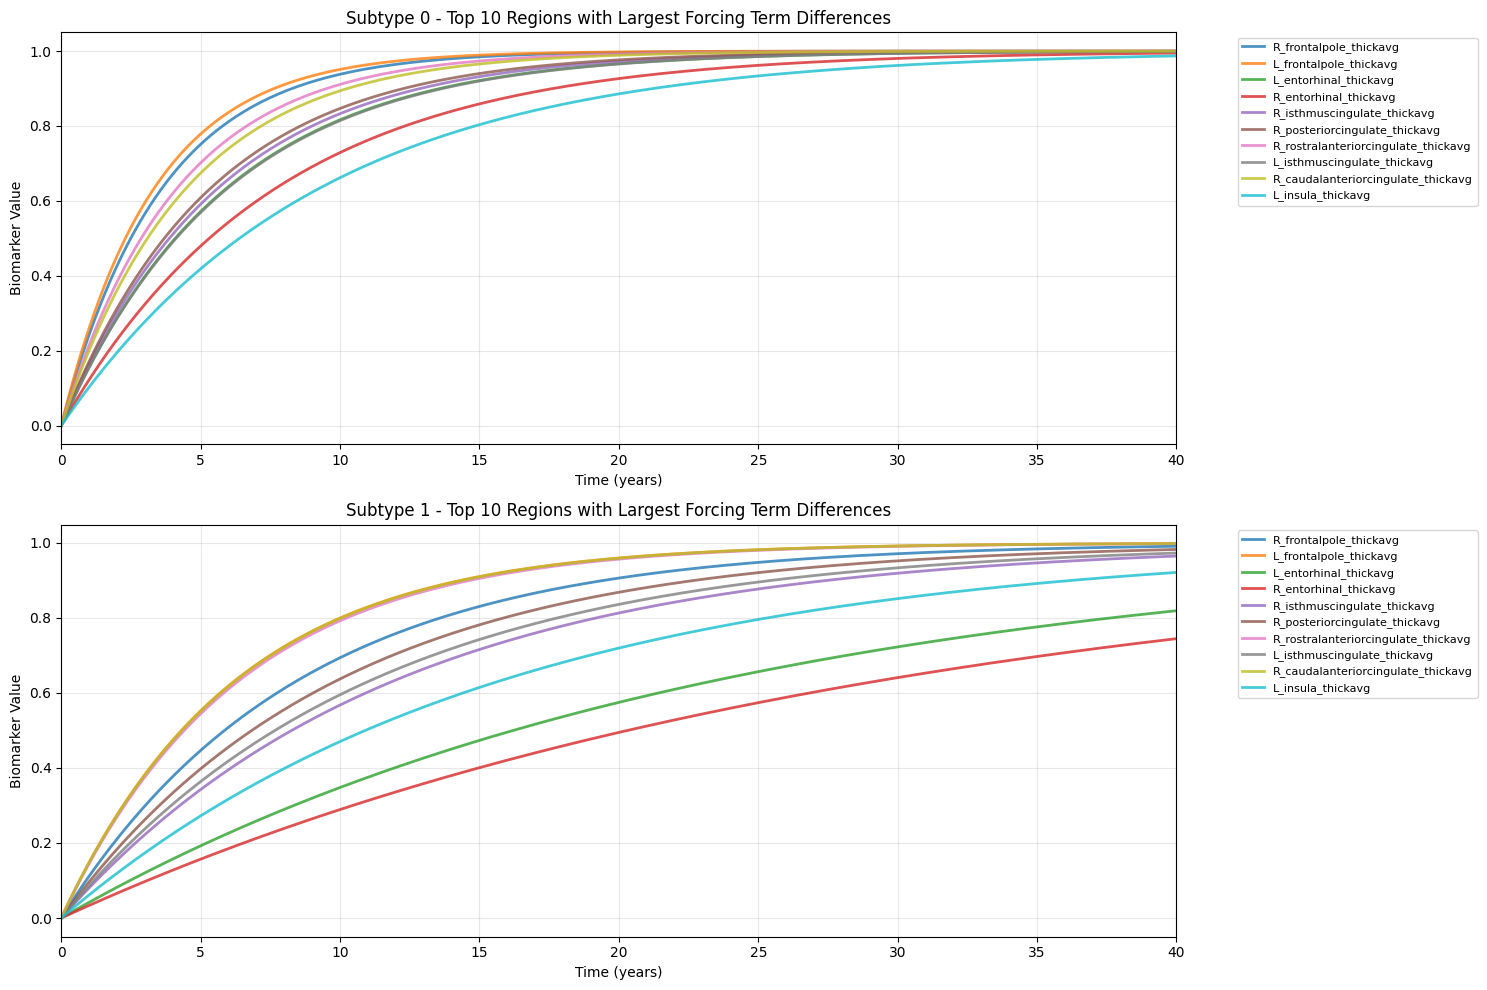

In [196]:
# ROI Subplots: Top 10 regions with largest forcing term differences

cluster_f = best_data["cluster_f"] # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# Per-ROI difference across all subtypes (works for any n_subtypes)
f_diff_max = np.zeros(n_biomarkers)
for i in range(n_subtypes):
    for j in range(i + 1, n_subtypes):
        f_diff_max = np.maximum(f_diff_max, np.abs(cluster_f[i] - cluster_f[j]))

top_n = 10
top_indices = np.argsort(f_diff_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)

    ax = axes[subtype]
    for i, roi_idx in enumerate(top_indices):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=top_ROI_names[i], linewidth=2, alpha=0.8)

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - Top 10 Regions with Largest Forcing Term Differences")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

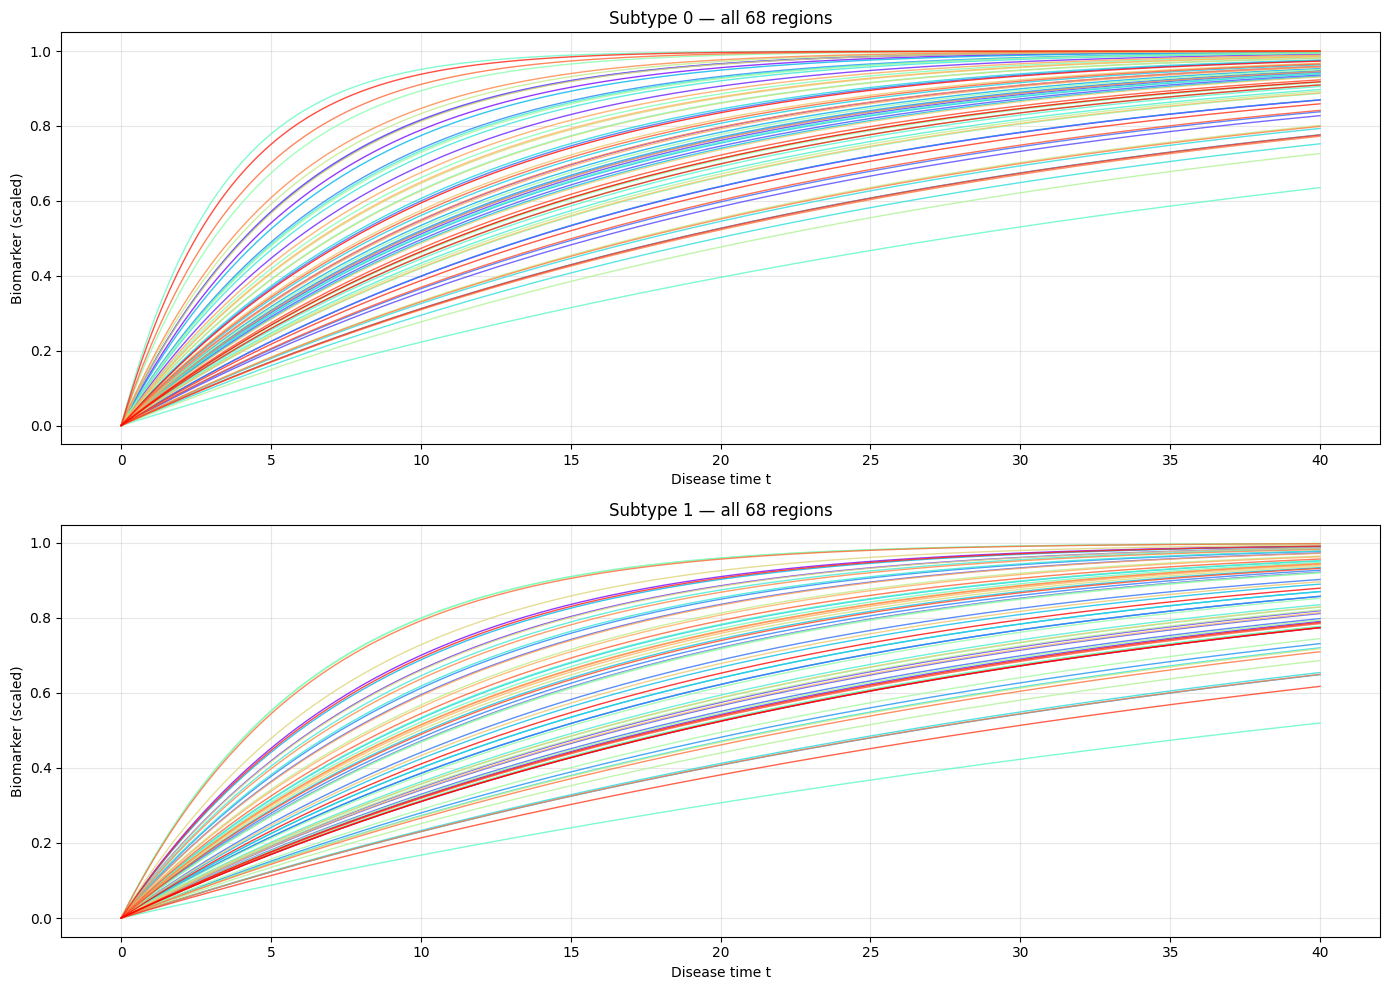

In [197]:
# Plot all 68 brain regions for each subtype (no legend; max-distinct colors)
import numpy as np
import matplotlib.pyplot as plt
from EMDPM.utils import solve_system

cluster_f = best_data["cluster_f"]
final_s = best_data["final_s"]
final_scalar_K = best_data["final_scalar_K"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# 68 distinct colors (rainbow-like)
colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))

fig, axes = plt.subplots(n_subtypes, 1, figsize=(14, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]
for subtype, ax in enumerate(axes):
    f_subtype = np.ravel(cluster_f[subtype])
    x0 = np.zeros(n_biomarkers)
    Xtraj = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
    for b in range(n_biomarkers):
        traj = Xtraj[b] #* final_s[b]
        ax.plot(t_span, traj, color=colors[b], alpha=0.8, linewidth=1)
    ax.set_xlabel("Disease time t")
    ax.set_ylabel("Biomarker (scaled)")
    ax.set_title(f"Subtype {subtype} — all {n_biomarkers} regions")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups
Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 5           95
1                                 7           39


<Figure size 1000x600 with 0 Axes>

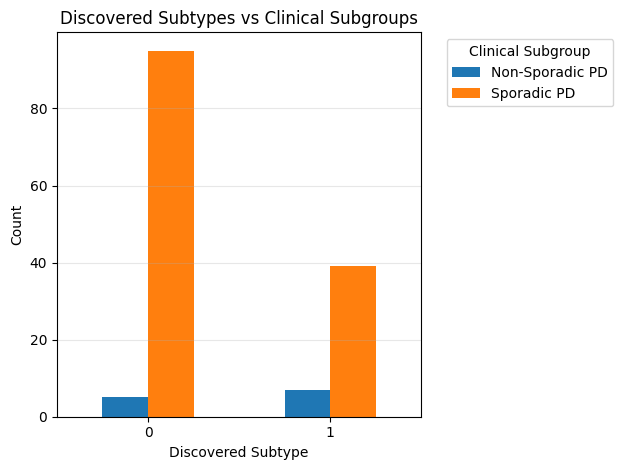

In [198]:
# Clinical Subgroup Comparison: Sporadic PD vs Non-Sporadic PD
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table
contingency = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup, name='Clinical Subgroup')
)
print("\nCONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups")
print(contingency)

plt.figure(figsize=(10, 6))
contingency.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 0 Beta Statistics:
  Mean: 16.2820
  Median: 14.0126
  Std: 7.8108

Subtype 1 Beta Statistics:
  Mean: 22.6914
  Median: 21.7755
  Std: 8.2529


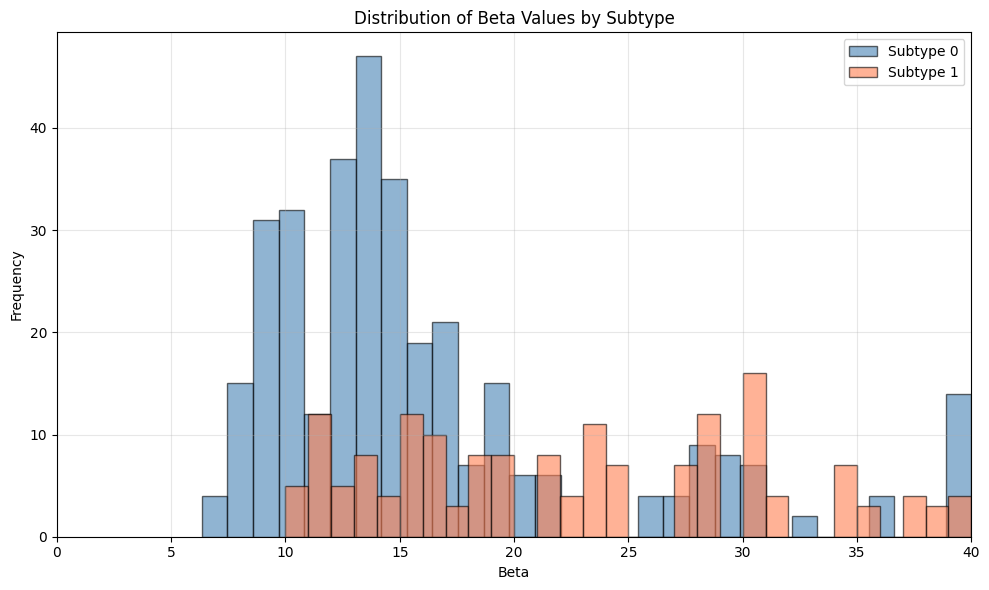

In [199]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'forestgreen', 'purple']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.xlim(0, 40)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


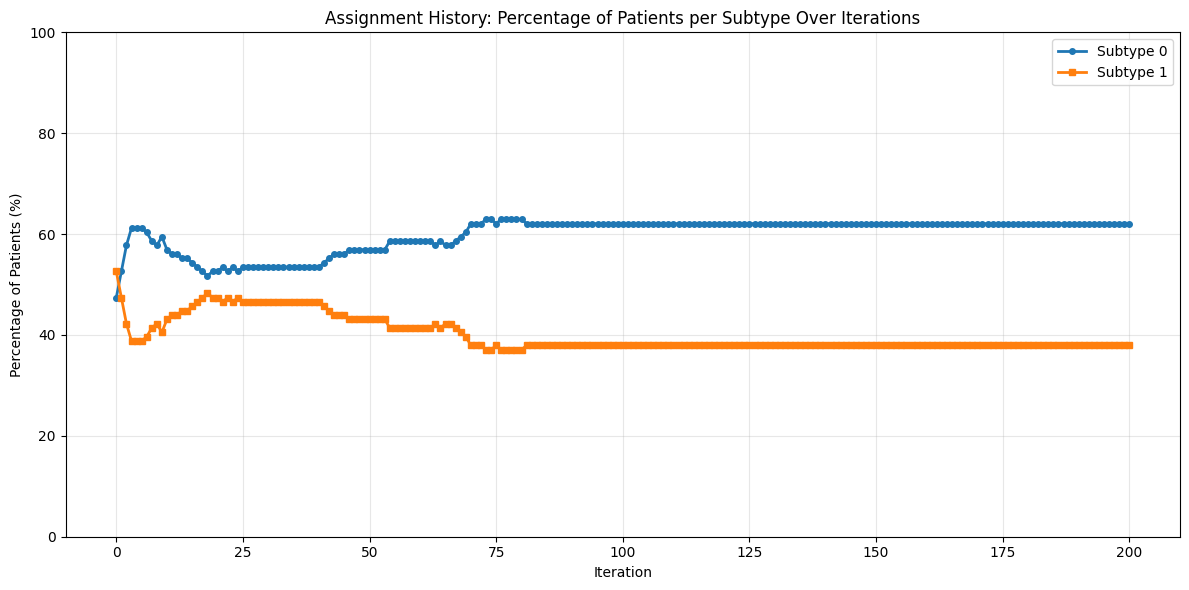

In [200]:
# Plot assignment history over iterations
if "assignment_history" in best_data.files:
    assignment_history = best_data["assignment_history"]  # (n_patients, n_iterations+1)
    n_iterations = assignment_history.shape[1] - 1
    
    # Calculate percentage of subtype 0 and 1 for each iteration
    pct_subtype0 = []
    pct_subtype1 = []
    
    for iter_idx in range(n_iterations + 1):
        assignments_iter = assignment_history[:, iter_idx]
        n_patients = len(assignments_iter)
        n_subtype0 = np.sum(assignments_iter == 0)
        n_subtype1 = np.sum(assignments_iter == 1)
        
        pct_subtype0.append(100 * n_subtype0 / n_patients)
        pct_subtype1.append(100 * n_subtype1 / n_patients)
    
    # Plot
    plt.figure(figsize=(12, 6))
    iterations = np.arange(n_iterations + 1)
    plt.plot(iterations, pct_subtype0, label='Subtype 0', linewidth=2, marker='o', markersize=4)
    plt.plot(iterations, pct_subtype1, label='Subtype 1', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Percentage of Patients (%)')
    plt.title('Assignment History: Percentage of Patients per Subtype Over Iterations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

Overall agreement between 'with cog' and 'no cog': 100.0% (30/30 patients)
Patients who changed subtype: 0/30

=== Agreement by Clinical Variable ===
(Shown as: patients with agreement / total validation patients (30))
Clinical Subtype:
  Non-Sporadic PD: 2/30
  Sporadic PD: 28/30

MoCA:
  [20,30]: 28/30
  [10,20): 2/30

NSD:
  NSD 3+: 25/30
  NSD 2: 3/30
  No NSD: 2/30

HY:
  HY 1-2: 27/30
  HY 3: 3/30


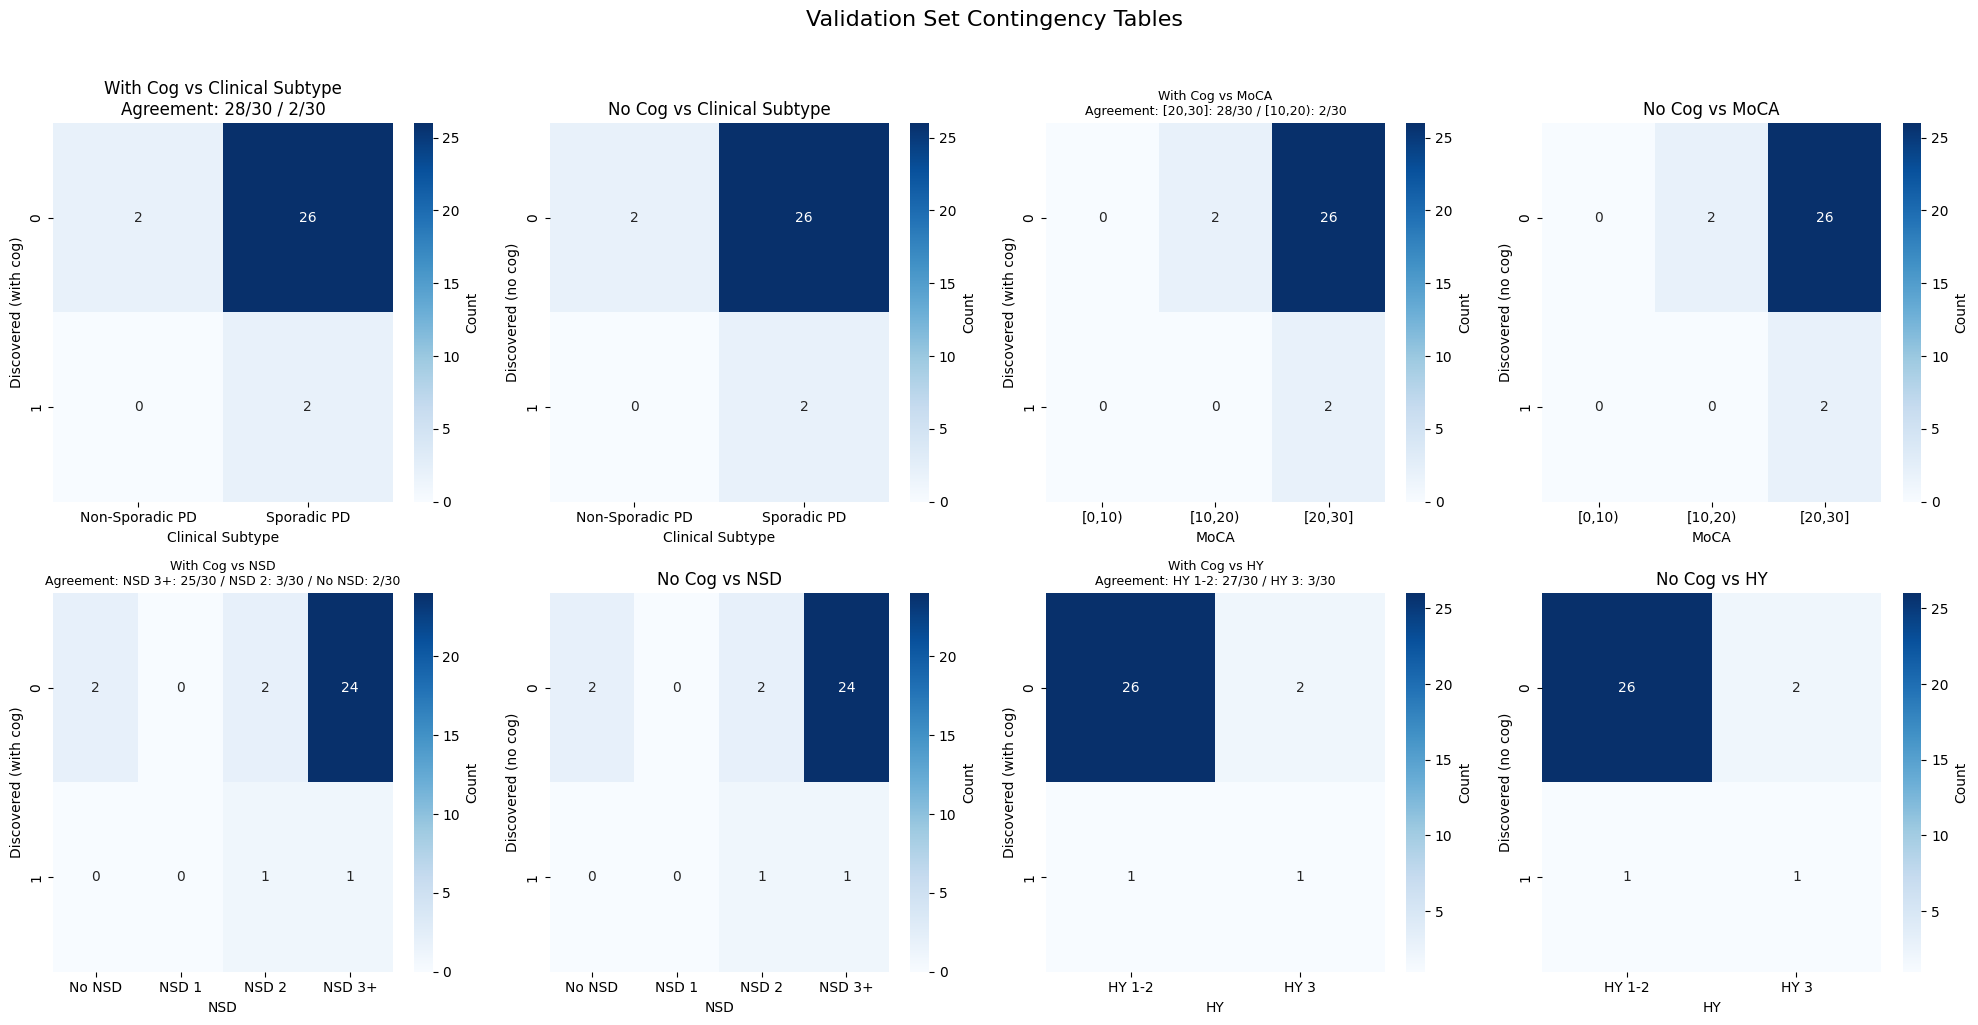

In [201]:
# Validation set contingency tables with visualizations
val_ids = best_data["val_ids"]
val_assignments_with_cog = best_data['val_assignments_with_cog']
val_assignments_no_cog = best_data['val_assignments_no_cog']

# Calculate overall agreement (same subtype assignment regardless of which subtype)
agreements = [val_assignments_with_cog[i] == val_assignments_no_cog[i] for i in range(len(val_ids))]
agreement_pct = 100 * np.mean(agreements)
n_agree = np.sum(agreements)
n_disagree = len(val_ids) - n_agree
print(f"Overall agreement between 'with cog' and 'no cog': {agreement_pct:.1f}% ({n_agree}/{len(val_ids)} patients)")
print(f"Patients who changed subtype: {n_disagree}/{len(val_ids)}")

# Get clinical variables per patient using FINAL observation (most recent time point)
pid_to_clinical = {}
pid_to_moca = {}
pid_to_nsd = {}
pid_to_hy = {}

for pid in val_ids:
    mask = df['subj_id'] == pid
    patient_df = df.loc[mask].copy()
    
    # Get final observation (maximum time)
    final_idx = patient_df['time'].idxmax()
    final_row = patient_df.loc[final_idx]
    
    # Clinical subtype
    subgroup = final_row['subgroup']
    pid_to_clinical[pid] = 'Sporadic PD' if subgroup == 'Sporadic PD' else 'Non-Sporadic PD'
    
    # Clinical scores from final observation
    pid_to_moca[pid] = final_row['MCATOT']
    pid_to_nsd[pid] = final_row['NSD_STAGE']
    pid_to_hy[pid] = final_row['NHY']

# Prepare data with proper binning
clinical = [pid_to_clinical[pid] for pid in val_ids]

# MoCA: [0,10), [10,20), [20,30]
moca_binned = []
for pid in val_ids:
    m = pid_to_moca[pid]
    if np.isnan(m):
        moca_binned.append('[0,10)')
    elif m < 10:
        moca_binned.append('[0,10)')
    elif m < 20:
        moca_binned.append('[10,20)')
    else:
        moca_binned.append('[20,30]')

# NSD: No NSD (0), 1, 2, 3+
nsd_binned = []
for pid in val_ids:
    n = pid_to_nsd[pid]
    if np.isnan(n) or n == 0:
        nsd_binned.append('No NSD')
    elif n == 1:
        nsd_binned.append('NSD 1')
    elif n == 2:
        nsd_binned.append('NSD 2')
    else:
        nsd_binned.append('NSD 3+')

# HY: HY 1-2, HY 3, HY 4-5
hy_binned = ['HY 1-2' if h <= 2 else 'HY 3' if h <= 3 else 'HY 4-5' for h in [pid_to_hy[pid] for pid in val_ids]]

# Calculate agreement for each clinical variable category (same vs different subtype)
def calc_agreement_by_category(categories, assignments_with, assignments_no, total_patients):
    agreement_by_cat = {}
    for cat in set(categories):
        mask = [c == cat for c in categories]
        if sum(mask) > 0:
            with_cat = [assignments_with[i] for i in range(len(mask)) if mask[i]]
            no_cat = [assignments_no[i] for i in range(len(mask)) if mask[i]]
            agreements = [with_cat[i] == no_cat[i] for i in range(len(with_cat))]
            n_agree = np.sum(agreements)
            agreement_by_cat[cat] = f"{n_agree}/{total_patients}"
    return agreement_by_cat

total_val_patients = len(val_ids)
clinical_agreement = calc_agreement_by_category(clinical, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)
moca_agreement = calc_agreement_by_category(moca_binned, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)
nsd_agreement = calc_agreement_by_category(nsd_binned, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)
hy_agreement = calc_agreement_by_category(hy_binned, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)

print("\n=== Agreement by Clinical Variable ===")
print(f"(Shown as: patients with agreement / total validation patients ({total_val_patients}))")
print("Clinical Subtype:")
for cat, ag in clinical_agreement.items():
    print(f"  {cat}: {ag}")
print("\nMoCA:")
for cat, ag in moca_agreement.items():
    print(f"  {cat}: {ag}")
print("\nNSD:")
for cat, ag in nsd_agreement.items():
    print(f"  {cat}: {ag}")
print("\nHY:")
for cat, ag in hy_agreement.items():
    print(f"  {cat}: {ag}")

# Create visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Validation Set Contingency Tables', fontsize=16, y=1.02)

# 1. With cog vs Clinical
ct1 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(clinical, name='Clinical Subtype'))
sns.heatmap(ct1, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar_kws={'label': 'Count'})
axes[0,0].set_title(f'With Cog vs Clinical Subtype\nAgreement: {clinical_agreement.get("Sporadic PD", "N/A")} / {clinical_agreement.get("Non-Sporadic PD", "N/A")}')

# 2. No cog vs Clinical
ct2 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(clinical, name='Clinical Subtype'))
sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues', ax=axes[0,1], cbar_kws={'label': 'Count'})
axes[0,1].set_title('No Cog vs Clinical Subtype')

# 3. With cog vs MoCA
ct3 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(moca_binned, name='MoCA'))
for bin_name in ['[0,10)', '[10,20)', '[20,30]']:
    if bin_name not in ct3.columns:
        ct3[bin_name] = 0
ct3 = ct3[['[0,10)', '[10,20)', '[20,30]']]
sns.heatmap(ct3, annot=True, fmt='d', cmap='Blues', ax=axes[0,2], cbar_kws={'label': 'Count'})
moca_title = 'With Cog vs MoCA\nAgreement: ' + ' / '.join([f"{k}: {v}" for k, v in moca_agreement.items()])
axes[0,2].set_title(moca_title, fontsize=9)

# 4. No cog vs MoCA
ct4 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(moca_binned, name='MoCA'))
for bin_name in ['[0,10)', '[10,20)', '[20,30]']:
    if bin_name not in ct4.columns:
        ct4[bin_name] = 0
ct4 = ct4[['[0,10)', '[10,20)', '[20,30]']]
sns.heatmap(ct4, annot=True, fmt='d', cmap='Blues', ax=axes[0,3], cbar_kws={'label': 'Count'})
axes[0,3].set_title('No Cog vs MoCA')

# 5. With cog vs NSD
ct5 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(nsd_binned, name='NSD'))
for cat in ['No NSD', 'NSD 1', 'NSD 2', 'NSD 3+']:
    if cat not in ct5.columns:
        ct5[cat] = 0
ct5 = ct5[['No NSD', 'NSD 1', 'NSD 2', 'NSD 3+']]
sns.heatmap(ct5, annot=True, fmt='d', cmap='Blues', ax=axes[1,0], cbar_kws={'label': 'Count'})
nsd_title = 'With Cog vs NSD\nAgreement: ' + ' / '.join([f"{k}: {v}" for k, v in nsd_agreement.items()])
axes[1,0].set_title(nsd_title, fontsize=9)

# 6. No cog vs NSD
ct6 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(nsd_binned, name='NSD'))
for cat in ['No NSD', 'NSD 1', 'NSD 2', 'NSD 3+']:
    if cat not in ct6.columns:
        ct6[cat] = 0
ct6 = ct6[['No NSD', 'NSD 1', 'NSD 2', 'NSD 3+']]
sns.heatmap(ct6, annot=True, fmt='d', cmap='Blues', ax=axes[1,1], cbar_kws={'label': 'Count'})
axes[1,1].set_title('No Cog vs NSD')

# 7. With cog vs HY
ct7 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(hy_binned, name='HY'))
sns.heatmap(ct7, annot=True, fmt='d', cmap='Blues', ax=axes[1,2], cbar_kws={'label': 'Count'})
hy_title = 'With Cog vs HY\nAgreement: ' + ' / '.join([f"{k}: {v}" for k, v in hy_agreement.items()])
axes[1,2].set_title(hy_title, fontsize=9)

# 8. No cog vs HY
ct8 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(hy_binned, name='HY'))
sns.heatmap(ct8, annot=True, fmt='d', cmap='Blues', ax=axes[1,3], cbar_kws={'label': 'Count'})
axes[1,3].set_title('No Cog vs HY')

plt.tight_layout()
plt.show()

In [202]:
# Load PPMI data to get NHY values
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
nhy_all = df["NHY"].to_numpy()
ids_all = df["subj_id"].to_numpy()

pid_to_nhy = {}
for pid in np.unique(ids_all):
    mask = ids_all == pid
    pid_to_nhy[pid] = np.mean(nhy_all[mask])


correlation_summary = []

for cand, data in results.items():
    try:
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        if "train_ids" not in data.files or "beta_history" not in data.files:
            continue
            
        train_ids = data["train_ids"]
        beta_history = data["beta_history"]
        beta_train = beta_history[:, -1]  # Final iteration beta values
        
        # Match beta to NHY
        beta_vals = []
        nhy_vals = []
        for pid, beta in zip(train_ids, beta_train):
            if pid in pid_to_nhy:
                beta_vals.append(beta)
                nhy_vals.append(pid_to_nhy[pid])
        
        if len(beta_vals) < 2:
            continue
            
        # Compute Kendall tau correlation
        tau, p_value = kendalltau(beta_vals, nhy_vals)
        
        # Extract lambda parameters for summary
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        
        correlation_summary.append({
            "candidate": candidate_num,
            "key": cand,
            "kendall_tau": tau,
            "p_value": p_value,
            "lambda_cog": lambda_cog,
            "lambda_jsd": lambda_jsd,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

corr_df = pd.DataFrame(correlation_summary)

if len(corr_df) > 0:
    # Sort by absolute Kendall tau (descending)
    corr_df["abs_kendall_tau"] = corr_df["kendall_tau"].abs()
    corr_df = corr_df.sort_values("abs_kendall_tau", ascending=False).reset_index(drop=True)
    
    print("\n=== Summary Statistics (sorted by |Kendall tau|) ===")
    print(corr_df[["candidate", "kendall_tau", "p_value", "lambda_cog", "lambda_jsd"]].head(10))
    
    # Get best correlation model
    best_corr_idx = 0  # Already sorted, so first row is best
    best_corr = corr_df.iloc[best_corr_idx]
    
    print(f"\n=== Best Model (Highest |Kendall tau|) ===")
    print(f"Candidate: {int(best_corr['candidate'])}")
    print(f"Kendall tau: {best_corr['kendall_tau']:.6f}")
    print(f"P-value: {best_corr['p_value']:.6f}")
    
    # Get parameters for best correlation model
    best_corr_data = results[best_corr['key']]
    if "lambda_f" in best_corr_data.files:
        print(f"\nParameters:")
        print(f"  lambda_f: {best_corr_data['lambda_f']}")
        print(f"  lambda_cog: {best_corr_data['lambda_cog']}")
        print(f"  lambda_scalar: {best_corr_data['lambda_scalar']}")
        print(f"  lambda_jsd: {best_corr_data['lambda_jsd']}")
        print(f"  lambda_beta: {best_corr_data['lambda_beta']}")
    
    # Print training subtype counts
    if "train_assignments" in best_corr_data.files:
        train_assignments = best_corr_data['train_assignments']
        n_subtypes = len(np.unique(train_assignments))
        print(f"\nTraining subtype counts:")
        for subtype in range(n_subtypes):
            print(f"  Subtype {subtype}: {np.sum(train_assignments == subtype)}")
else:
    print("No valid correlations found")


=== Summary Statistics (sorted by |Kendall tau|) ===
  candidate  kendall_tau       p_value lambda_cog lambda_jsd
0       172     0.357174  1.271713e-07        0.5       1000
1       269     0.344528  3.478879e-07        0.5     100000
2       224     0.336223  6.592437e-07        0.5     100000
3       353     0.335066  7.213708e-07        0.5      10000
4        83     0.324734  1.562519e-06        0.5      10000
5        80     0.316962  2.757326e-06        0.5          0
6        42     0.316962  2.757326e-06        0.5       1000
7       393     0.315611  3.039633e-06        0.5      10000
8        35     0.315273  3.114428e-06        0.5          0
9       303     0.315151  3.152134e-06        0.5      10000

=== Best Model (Highest |Kendall tau|) ===
Candidate: 172
Kendall tau: 0.357174
P-value: 0.000000

Parameters:
  lambda_f: 0.25
  lambda_cog: 0.5
  lambda_scalar: 0.8
  lambda_jsd: 1000
  lambda_beta: 0.0

Training subtype counts:
  Subtype 0: 47
  Subtype 1: 9
  Subtype 2:

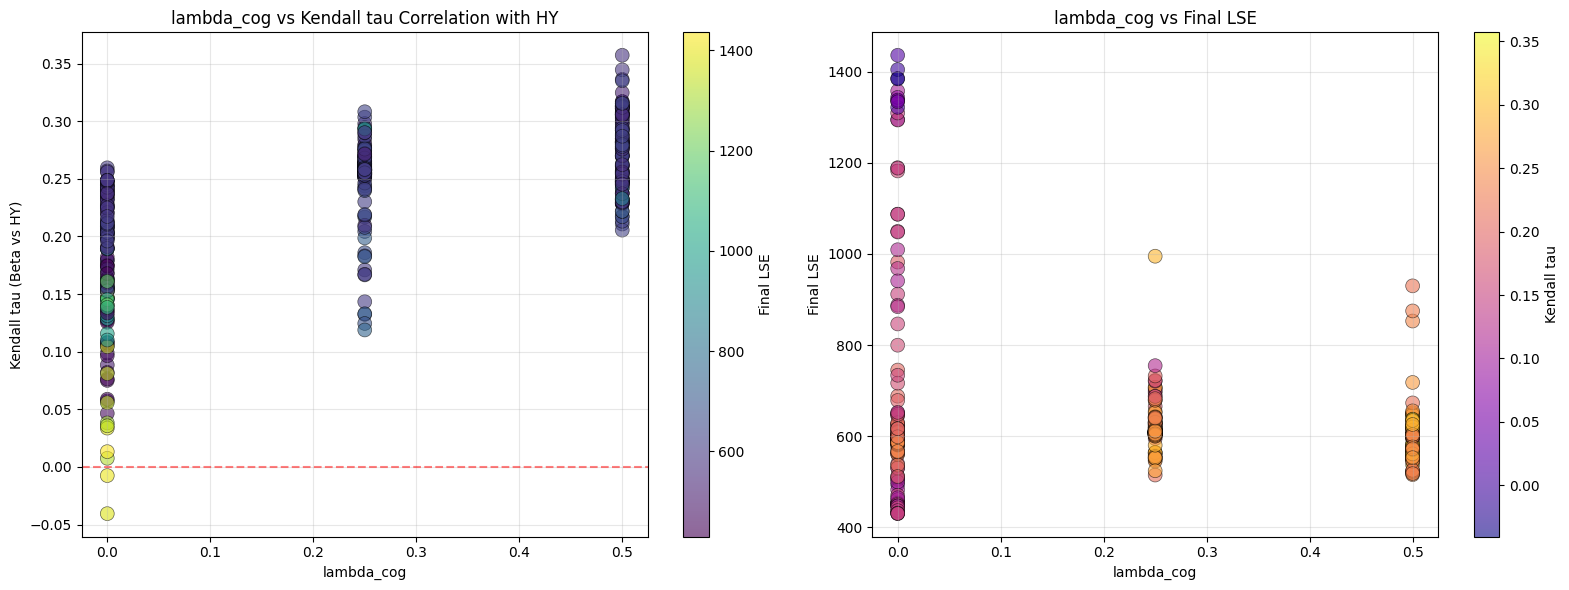

In [203]:
correlation_with_lse = []
for cand, data in results.items():
    try:
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        if "train_ids" not in data.files or "beta_history" not in data.files:
            continue
            
        train_ids = data["train_ids"]
        beta_history = data["beta_history"]
        beta_train = beta_history[:, -1]
        
        # Match beta to NHY
        beta_vals = []
        nhy_vals = []
        for pid, beta in zip(train_ids, beta_train):
            if pid in pid_to_nhy:
                beta_vals.append(beta)
                nhy_vals.append(pid_to_nhy[pid])
        
        if len(beta_vals) < 2:
            continue
            
        # Compute Kendall tau correlation
        tau, p_value = kendalltau(beta_vals, nhy_vals)
        
        # Get LSE
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan
        
        # Extract lambda parameters
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        
        correlation_with_lse.append({
            "candidate": candidate_num,
            "key": cand,
            "kendall_tau": tau,
            "p_value": p_value,
            "final_lse": final_lse,
            "lambda_cog": lambda_cog,
            "lambda_jsd": lambda_jsd,
        })
    except Exception as e:
        continue

corr_lse_df = pd.DataFrame(correlation_with_lse)

if len(corr_lse_df) > 0:
    # Create scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: lambda_cog vs Kendall tau
    scatter1 = axes[0].scatter(corr_lse_df['lambda_cog'], corr_lse_df['kendall_tau'], 
                               c=corr_lse_df['final_lse'], cmap='viridis', 
                               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel('lambda_cog')
    axes[0].set_ylabel('Kendall tau (Beta vs HY)')
    axes[0].set_title('lambda_cog vs Kendall tau Correlation with HY')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Final LSE')
    
    # Plot 2: lambda_cog vs LSE
    scatter2 = axes[1].scatter(corr_lse_df['lambda_cog'], corr_lse_df['final_lse'], 
                               c=corr_lse_df['kendall_tau'], cmap='plasma', 
                               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[1].set_xlabel('lambda_cog')
    axes[1].set_ylabel('Final LSE')
    axes[1].set_title('lambda_cog vs Final LSE')
    axes[1].grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Kendall tau')
    
    plt.tight_layout()
    plt.show()